In [2]:
%load_ext autoreload
%autoreload 2

## 1. The model

In [3]:
import numpy as np
from Python_module import ConsumerClass

# a. both calibrations, kept in one dictionary so we can loop over them
#    together in every later assignment instead of writing everything twice
models = {
    'Complements': ConsumerClass(),
    'Substitutes': ConsumerClass(par={'sigma_B': 3.00}),
}

# b. print both, to check the parameters really are what we expect
for name, model in models.items():
    print(name)
    print(model)
    print()

Complements
ConsumerClass
  alpha = 0.60, beta = 0.50
  sigma_A = 0.80, sigma_B = 0.40
  p1 = 1.00, p2 = 1.00, p3 = 1.50, I = 10.00

Substitutes
ConsumerClass
  alpha = 0.60, beta = 0.50
  sigma_A = 0.80, sigma_B = 3.00
  p1 = 1.00, p2 = 1.00, p3 = 1.50, I = 10.00



Both printouts match the calibration table above, and `sigma_B` is the only parameter that differs between them -- so the two calibrations are set up correctly, and `par={'sigma_B':3.0}` really did only change that one number.

### 1.2 Testing `.utility()` 

Before trusting `.utility()`, we check it on bundles we can reason about by hand, without needing to solve anything:

1. If $x_1=x_2=x_3=1$, both nests reduce to a weighted average of two identical numbers, so utility should come out at exactly $1$ -- whatever the weights and elasticities are.
2. Getting *more* of one good, holding the others fixed, should never lower utility.

In [4]:
# a. check 1: equal quantities should give utility of exactly 1
for name, model in models.items():
    u = model.utility(1.0, 1.0, 1.0)
    print(f'{name}: u(1,1,1) = {u:.4f}')

print()

# b. check 2: more food should not make the consumer worse off
model = models['Complements']
u_base = model.utility(1.0, 1.0, 1.0)
u_more_food = model.utility(2.0, 1.0, 1.0)
print(f'u(1,1,1) = {u_base:.4f}')
print(f'u(2,1,1) = {u_more_food:.4f}')
print(f'more food increases utility: {u_more_food > u_base}')

Complements: u(1,1,1) = 1.0000
Substitutes: u(1,1,1) = 1.0000

u(1,1,1) = 1.0000
u(2,1,1) = 1.4938
more food increases utility: True


Both checks come out the way they should: utility is exactly $1$ in the equal bundle for both calibrations, and doubling the food quantity raises utility. `.utility()` looks correctly specified.

### 1.3 From nested shares to quantities

`.shares(s1,w)` turns a choice of $(s_1,w)$ into the three budget shares (eq. 3 in the assignment), and `.quantities(s1,w)` turns those into the actual quantities $x_1,x_2,x_3$, using the prices and income in `par`. We try this out at five points: the middle of the square and its four corners -- points we will come back to in the next assignment, to start the optimizer from several different places.

In [5]:
# a. the points we will keep re-using in later assignments
points = {
    'middle': (0.5, 0.5),
    'corner (0,0)': (0.0, 0.0),
    'corner (0,1)': (0.0, 1.0),
    'corner (1,0)': (1.0, 0.0),
    'corner (1,1)': (1.0, 1.0),
}

model = models['Complements']

for name, (s1, w) in points.items():
    s1_share, s2, s3 = model.shares(s1, w)
    x1, x2, x3 = model.quantities(s1, w)
    total = s1_share + s2 + s3
    print(f'{name:>13}: shares=({s1_share:.2f},{s2:.2f},{s3:.2f}) sum={total:.2f}  '
          f'quantities=({x1:.2f},{x2:.2f},{x3:.2f})')

       middle: shares=(0.50,0.25,0.25) sum=1.00  quantities=(5.00,2.50,1.67)
 corner (0,0): shares=(0.00,0.00,1.00) sum=1.00  quantities=(0.00,0.00,6.67)
 corner (0,1): shares=(0.00,1.00,0.00) sum=1.00  quantities=(0.00,10.00,0.00)
 corner (1,0): shares=(1.00,0.00,0.00) sum=1.00  quantities=(10.00,0.00,0.00)
 corner (1,1): shares=(1.00,0.00,0.00) sum=1.00  quantities=(10.00,0.00,0.00)


The three shares sum to 1 at every point, exactly as the reparametrization promises, and every quantity comes out non-negative. A corner just means "spend nothing" on one or two goods (e.g. corner (0,1) spends the whole budget on food, so both travel quantities are zero, not negative or undefined).

One thing is worth noticing: corners (1,0) and (1,1) give the *same* shares. That makes sense once we think about it -- $s_1=1$ already spends the entire income on food, so there is no travel budget left, and $w$ (the split of a budget of *zero*) stops mattering. Good to keep in mind before the next assignment searches this square for the best point.

### 1.4 shares straight to utility

Putting the last two pieces together, the assignment's objective (eq. 4, without the outer $\max$ yet) is

$$
u\!\left(\frac{s_1 I}{p_1},\ \frac{(1-s_1)wI}{p_2},\ \frac{(1-s_1)(1-w)I}{p_3}\right)
$$

Here we calculate the choice of $(s_1,w)$ directly as a utility number. We do this because it is exactly the function the optimizer will be handed in the next assignment, so it is worth checking now that it agrees with calling `.quantities()` and `.utility()` seperately, one after another.

In [6]:
s1, w = 0.5, 0.5

for name, model in models.items():

    # a. the two-step way
    x1, x2, x3 = model.quantities(s1, w)
    u_manual = model.utility(x1, x2, x3)

    # b. the shortcut
    u_direct = model.value_of_choice(s1, w)

    print(f'{name}: manual = {u_manual:.6f}, value_of_choice = {u_direct:.6f}, '
          f'agree = {np.isclose(u_manual, u_direct)}')

Complements: manual = 3.363085, value_of_choice = 3.363085, agree = True
Substitutes: manual = 3.431165, value_of_choice = 3.431165, agree = True


They agree exactly, as they should. Using the shortcut does nothing but call the other two methods in order.

Notice also that at the same point (s_1,w)=(0.5,0.5), the two calibrations already give different utility levels. That does not yet tell us which (s_1,w) is 'best' for either consumer, only that the model reacts to $\sigma_B$. Finding the best point once with a grid search, and once with `scipy.optimize.minimize`.

## 2. Solving the model numerically

Now we actually solve the model: once with a brute-force grid search, once with `scipy.optimize.minimize` (L-BFGS-B). Both get added to `ConsumerClass`, as `.solve_grid()` and `.solve()`.

### 2.1 Grid search

`.solve_grid(N)` checks utility at every point of an $N\times N$ grid over $(s_1,w)$ and keeps the best one.

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# a. solve both calibrations by grid search, and keep the results for plotting
grid_results = {name: model.solve_grid(N=200) for name, model in models.items()}

grid search, N = 200: (s1,w) = (0.5377,0.4372), u = 3.4016, evaluations = 40000
grid search, N = 200: (s1,w) = (0.5377,0.6935), u = 3.4851, evaluations = 40000


Both solutions are interior points, and `Substitutes` puts more of the travel budget on the bus (higher $w$) -- since bus and train substitute freely there, the consumer tilts hard towards the cheaper one. Plotted below, as a 3D surface and a contour, with the solution marked:

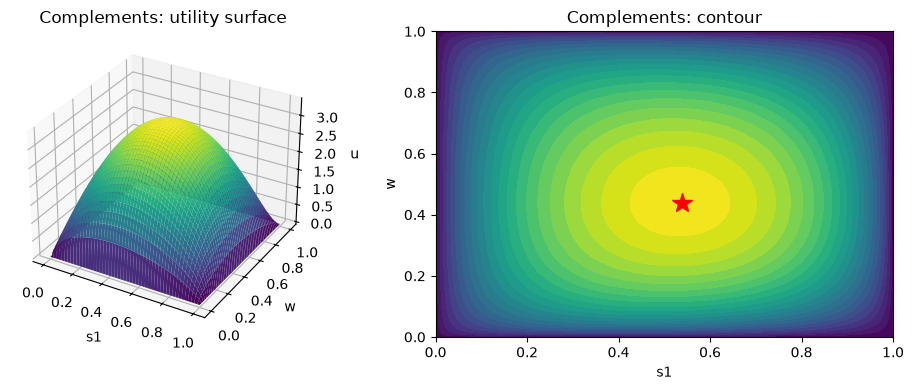

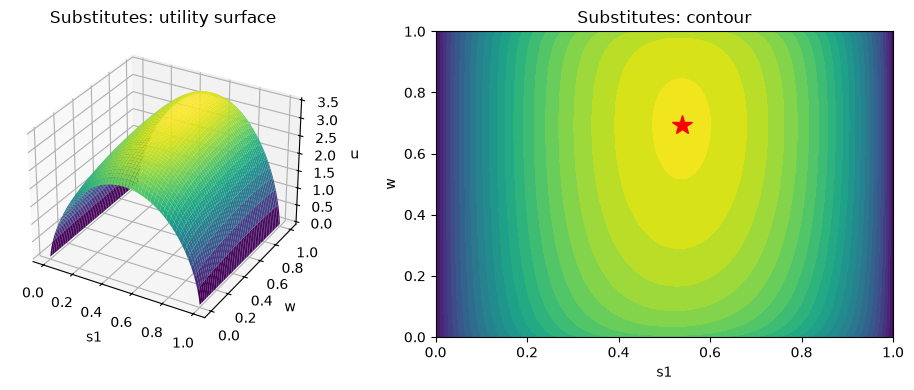

In [8]:
for name, opt in grid_results.items():
    fig = plt.figure(figsize=(10, 4))

    # a. utility surface
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    ax.plot_surface(opt.s1_grid, opt.w_grid, opt.u_grid, cmap='viridis')
    ax.set_xlabel('s1'); ax.set_ylabel('w'); ax.set_zlabel('u')
    ax.set_title(f'{name}: utility surface')

    # b. contour, with the solution marked
    ax = fig.add_subplot(1, 2, 2)
    ax.contourf(opt.s1_grid, opt.w_grid, opt.u_grid, levels=30, cmap='viridis')
    ax.plot(opt.s1, opt.w, 'r*', markersize=15)
    ax.set_xlabel('s1'); ax.set_ylabel('w')
    ax.set_title(f'{name}: contour')

    plt.tight_layout()
    plt.show()

We test how much $N$ matters. We try $N=50,100,500,1000$:

In [21]:
rows = []
for name, model in models.items():
    for N in [50, 100, 500, 1000]:
        opt = model.solve_grid(N=N, do_print=False)
        rows.append({'calibration': name, 'N': N, 's1': opt.s1, 'w': opt.w, 'u': opt.u, 'evaluations': N*N})

pd.DataFrame(rows).round(4)

,calibration,N,s1,w,u,evaluations
0,Complements,50,0.5306,0.4490,3.4007,2500
1,Complements,100,0.5354,0.4444,3.4015,10000
2,Complements,500,0.5351,0.4389,3.4017,250000
3,Complements,1000,0.5355,0.4394,3.4017,1000000
4,Substitutes,50,0.5306,0.6939,3.4846,2500
5,Substitutes,100,0.5354,0.6970,3.4850,10000
6,Substitutes,500,0.5391,0.6914,3.4851,250000
7,Substitutes,1000,0.5385,0.6927,3.4851,1000000


In [10]:
# how much sharper is the peak in one calibration than the other?
for name, opt in grid_results.items():
    frac_near_top = np.mean(opt.u_grid > 0.99 * opt.u_grid.max())
    print(f'{name}: {frac_near_top*100:.1f}% of grid points are within 1% of the best utility')

Complements: 1.3% of grid points are within 1% of the best utility
Substitutes: 3.2% of grid points are within 1% of the best utility


**2.1.3** Going from $N=50$ to $N=1000$ only moves $(s_1,w)$ in the 3rd decimal, but costs 400 times more evaluations ($50^2$ vs. $1000^2$) -- most of the improvement already happens by $N=100$. It improves smoothly, with no jumps.

**2.1.4** At $N=200$, only 1.3% of grid points land within 1% of the best utility in `Complements`, against 3.2% in `Substitutes` -- so `Complements` has a sharper, narrower peak, and turns out to be the harder one for an optimizer (see 2.2.3 below).

### 2.2 L-BFGS-B

Here we use `.solve()` to call  `scipy.optimize.minimize` with `method='L-BFGS-B'` and bounds `((0,1),(0,1))`. The box is the entire constraint, so nothing else is needed.

In [11]:
import time

# a. solve both calibrations, and compare with the grid search (N=1000, our most precise one)
rows = []
for name, model in models.items():
    t0 = time.perf_counter(); grid = model.solve_grid(N=1000, do_print=False); t1 = time.perf_counter()
    t2 = time.perf_counter(); lbfgsb = model.solve(do_print=False); t3 = time.perf_counter()
    rows.append({'calibration': name, 'method': 'grid (N=1000)', 's1': grid.s1, 'w': grid.w, 'u': grid.u,
                 'evaluations': 1_000_000, 'time_ms': (t1-t0)*1000})
    rows.append({'calibration': name, 'method': 'L-BFGS-B', 's1': lbfgsb.s1, 'w': lbfgsb.w, 'u': lbfgsb.u,
                 'evaluations': lbfgsb.res.nfev, 'time_ms': (t3-t2)*1000})

pd.DataFrame(rows).round(4)

,calibration,method,s1,w,u,evaluations,time_ms
0,Complements,grid (N=1000),0.5355,0.4394,3.4017,1000000,166.1111
1,Complements,L-BFGS-B,0.5356,0.4395,3.4017,18,27.1828
2,Substitutes,grid (N=1000),0.5385,0.6927,3.4851,1000000,168.2305
3,Substitutes,L-BFGS-B,0.5382,0.6923,3.4851,27,4.2353


They agree to about 4 decimals, but L-BFGS-B gets there with a few dozen evaluations instead of a million. And is much faster.

**2.2.2 -- the convergence path.** We track it with a `callback`, starting from corner $(0,0)$, and draw it on top of the contour:

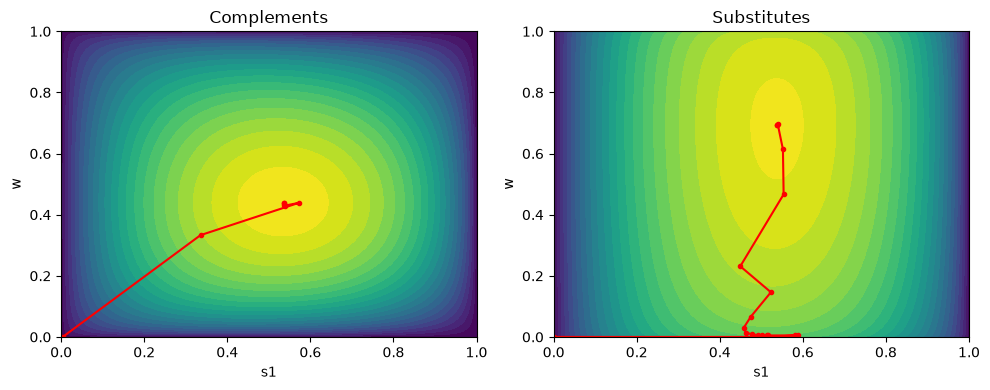

In [12]:
paths = {name: model.solve(s0=np.array([0.0, 0.0]), do_print=False) for name, model in models.items()}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, opt) in zip(axes, paths.items()):
    grid = grid_results[name]
    ax.contourf(grid.s1_grid, grid.w_grid, grid.u_grid, levels=30, cmap='viridis')
    ax.plot(opt.path[:, 0], opt.path[:, 1], 'r.-')
    ax.set_xlabel('s1'); ax.set_ylabel('w'); ax.set_title(name)

plt.tight_layout()
plt.show()

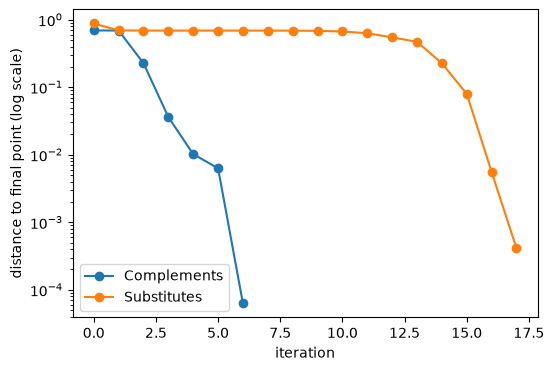

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, opt in paths.items():
    dist_to_final = np.linalg.norm(opt.path - opt.path[-1], axis=1)
    ax.semilogy(dist_to_final[:-1], marker='o', label=name)  # drop the last point: distance 0

ax.set_xlabel('iteration')
ax.set_ylabel('distance to final point (log scale)')
ax.legend()
plt.show()

The two calibrations look quite different here. `Complements` makes almost all of its progress in a couple of big steps around iteration 2-6. `Substitutes` barely moves for its first eleven iterations -- matching the path plot above, where it creeps along the $w=0$ edge -- before finally correcting sharply in its last few steps.

**2.2.3 -- does the starting point matter?** We try six: the middle, all four corners, and one extra interior point.

In [14]:
starts = {
    'middle': (0.5, 0.5),
    'corner (0,0)': (0.0, 0.0),
    'corner (0,1)': (0.0, 1.0),
    'corner (1,0)': (1.0, 0.0),
    'corner (1,1)': (1.0, 1.0),
    'interior (0.2,0.8)': (0.2, 0.8),
}

rows = []
for name, model in models.items():
    for s_name, s0 in starts.items():
        opt = model.solve(s0=np.array(s0), do_print=False)
        rows.append({'calibration': name, 'start': s_name, 's1': opt.s1, 'w': opt.w, 'u': opt.u,
                     'iterations': opt.res.nit, 'success': opt.res.success})

pd.DataFrame(rows).round(4)

,calibration,start,s1,w,u,iterations,success
0,Complements,middle,0.5356,0.4395,3.4017,4,True
1,Complements,"corner (0,0)",0.5356,0.4395,3.4017,7,True
2,Complements,"corner (0,1)",0.5356,0.4395,3.4017,9,True
3,Complements,"corner (1,0)",1.0000,0.0000,0.0000,1,True
4,Complements,"corner (1,1)",1.0000,1.0000,0.0000,1,True
5,Complements,"interior (0.2,0.8)",0.5356,0.4395,3.4017,6,True
6,Substitutes,middle,0.5382,0.6923,3.4851,6,True
7,Substitutes,"corner (0,0)",0.5382,0.6923,3.4851,18,True
8,Substitutes,"corner (0,1)",0.5382,0.6923,3.4851,17,True
9,Substitutes,"corner (1,0)",0.5382,0.6923,3.4851,18,True


Every starting point finds the same answer. Except for two, in Complements: starting exactly at corner (1,0) or (1,1), the solver stops after a single iteration reporting `success = True`, at $u\approx0$. That is the worst point in the square, not the best.

Here is why: at $s_1=1$ there is no travel budget left, so bus and train are both (essentially) zero, and since $\sigma_A,\sigma_B<1$ in this calibration the consumer cannot substitute food for travel at all -- utility collapses towards zero right at that boundary ($u=0.01$ already at $s_1=0.9999$). It falls so fast that the gradient computed *exactly at* the corner is only about $10^{-14}$ -- far below the threshold L-BFGS-B uses to decide it has converged -- so it stops immediately, fooled into thinking it has already found the optimum. Starting just $0.0001$ away from the corner is enough to fix it.

**2.2.4 tolerance settings.** Varying ftol and gtol (holding the other at its default), for both calibrations:

In [15]:
rows = []
for name, model in models.items():
    for ftol in [1e-4, 1e-8, 1e-12, 1e-16]:
        opt = model.solve(do_print=False, options={'ftol': ftol})
        rows.append({'calibration': name, 'setting': f'ftol={ftol:.0e}', 's1': opt.s1, 'w': opt.w,
                     'u': opt.u, 'evaluations': opt.res.nfev})
    for gtol in [1e-2, 1e-5, 1e-8, 1e-12]:
        opt = model.solve(do_print=False, options={'gtol': gtol})
        rows.append({'calibration': name, 'setting': f'gtol={gtol:.0e}', 's1': opt.s1, 'w': opt.w,
                     'u': opt.u, 'evaluations': opt.res.nfev})

pd.DataFrame(rows).round(6)

,calibration,setting,s1,w,u,evaluations
0,Complements,ftol=1e-04,0.535607,0.439652,3.401680,15
1,Complements,ftol=1e-08,0.535623,0.439479,3.401680,18
2,Complements,ftol=1e-12,0.535623,0.439479,3.401680,18
3,Complements,ftol=1e-16,0.535623,0.439479,3.401680,18
4,Complements,gtol=1e-02,0.535607,0.439652,3.401680,15
5,Complements,gtol=1e-05,0.535623,0.439479,3.401680,18
6,Complements,gtol=1e-08,0.535624,0.439478,3.401680,21
7,Complements,gtol=1e-12,0.535624,0.439478,3.401680,21
8,Substitutes,ftol=1e-04,0.538155,0.691562,3.485104,21
9,Substitutes,ftol=1e-08,0.538225,0.692308,3.485105,27


**2.2.5** Past roughly `1e-8`, tightening either setting further changes nothing. Same answer, same number of evaluations because floating-point arithmetic already can't tell the objective apart at that precision. The loosest settings (`ftol=1e-4`, `gtol=1e-2`) trade away a little precision for slightly fewer evaluations.

We would use the defaults (around `ftol=1e-8`, `gtol=1e-5`): tight enough to reach the best answer floating point allows, without paying for evaluations a tighter tolerance can't actually use here. A tighter tolerance is not automatically better, because past that point there is nothing left to gain -- you are just asking the solver to keep splitting hairs it cannot feel.

Next assignment: how demand responds as the price of a train ticket rises.

## 3. Relative prices and demand

Train tickets get more expensive: we solve the model for $p_3$ from 0.5 to 3.0 (holding $p_1$, $p_2$ and $I$ fixed) and see what the consumer does, in both calibrations.

In [17]:
# a. the calibrations, re-using each model's sigma_B so we don't retype it
sigma_B = {name: model.par.sigma_B for name, model in models.items()}

# b. solve the model at every p3, for both calibrations, and collect the results
p3_vec = np.linspace(0.5, 3.0, 50)

rows = []
for name, sB in sigma_B.items():
    for p3 in p3_vec:
        model = ConsumerClass(par={'sigma_B': sB, 'p3': p3})
        opt = model.solve(do_print=False)
        x1, x2, x3 = model.quantities(opt.s1, opt.w)
        rows.append({'calibration': name, 'p3': p3, 's1': opt.s1, 's2': opt.s2, 's3': opt.s3,
                     'x1': x1, 'x2': x2, 'x3': x3})

df = pd.DataFrame(rows)
df.head()

,calibration,p3,s1,s2,s3,x1,x2,x3
0,Complements,0.500000,0.561660,0.264099,0.174241,5.616601,2.640994,3.484810
1,Complements,0.551020,0.559724,0.259084,0.181193,5.597238,2.590836,3.288310
2,Complements,0.602041,0.557899,0.254443,0.187658,5.578987,2.544434,3.117029
3,Complements,0.653061,0.556171,0.250127,0.193702,5.561707,2.501274,2.966059
4,Complements,0.704082,0.554528,0.246094,0.199377,5.545283,2.460944,2.831736


Budget shares first, then quantities:

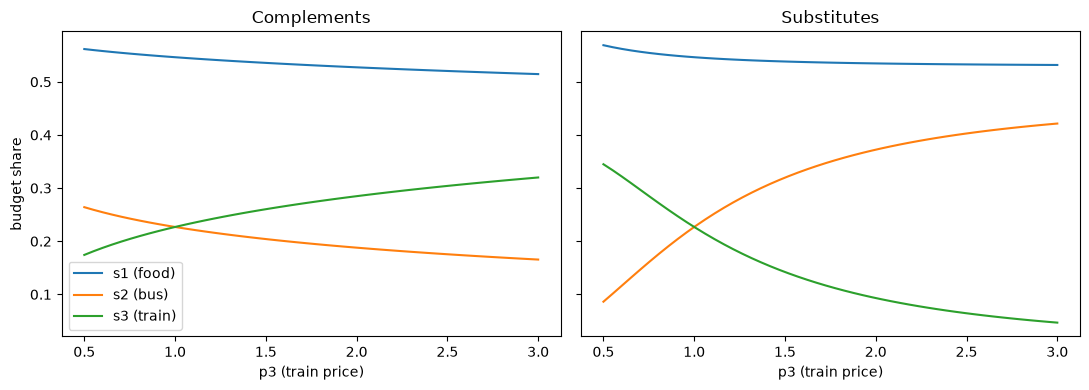

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, sigma_B):
    d = df[df.calibration == name]
    ax.plot(d.p3, d.s1, label='s1 (food)')
    ax.plot(d.p3, d.s2, label='s2 (bus)')
    ax.plot(d.p3, d.s3, label='s3 (train)')
    ax.set_xlabel('p3 (train price)')
    ax.set_title(name)

axes[0].set_ylabel('budget share')
axes[0].legend()
plt.tight_layout()
plt.show()

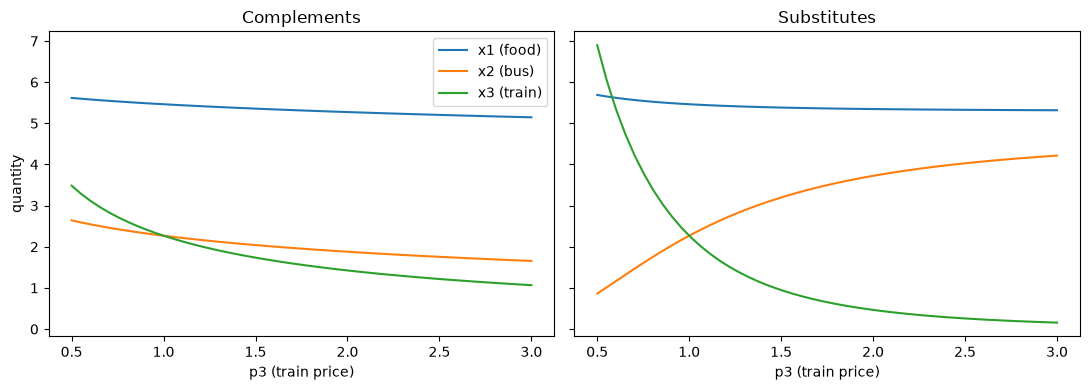

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, sigma_B):
    d = df[df.calibration == name]
    ax.plot(d.p3, d.x1, label='x1 (food)')
    ax.plot(d.p3, d.x2, label='x2 (bus)')
    ax.plot(d.p3, d.x3, label='x3 (train)')
    ax.set_xlabel('p3 (train price)')
    ax.set_title(name)

axes[0].set_ylabel('quantity')
axes[0].legend()
plt.tight_layout()
plt.show()

A short summary, comparing the two ends of the price range:

In [20]:
rows = []
for name in sigma_B:
    d = df[df.calibration == name]
    rows.append({
        'calibration': name,
        's3 @ p3=0.5': d.s3.iloc[0], 's3 @ p3=3.0': d.s3.iloc[-1],
        'x1 % change': 100*(d.x1.iloc[-1]/d.x1.iloc[0] - 1),
        'x2 % change': 100*(d.x2.iloc[-1]/d.x2.iloc[0] - 1),
        'x3 % change': 100*(d.x3.iloc[-1]/d.x3.iloc[0] - 1),
    })

pd.DataFrame(rows).round(2)

,calibration,s3 @ p3=0.5,s3 @ p3=3.0,x1 % change,x2 % change,x3 % change
0,Complements,0.17,0.32,-8.39,-37.33,-69.39
1,Substitutes,0.34,0.05,-6.54,388.83,-97.74


**3.2 -- train's budget share.** It rises in `Complements` (0.17 to 0.32) and falls in `Substitutes` (0.34 to 0.05): unable to substitute away, the `Complements` consumer keeps buying almost as much train even as it gets pricier, so spending on it grows; the `Substitutes` consumer flees to the bus instead, so spending on train collapses.

**3.3 -- bus trips.** They move *with* train in `Complements` (-37%: bus and train are used together, so cutting train means cutting bus too) and *against* it in `Substitutes` (+389%: bus absorbs the trips train loses).

**3.4 -- food demand.** Food barely reacts either way (-8.4% / -6.5%) -- it sits outside the travel nest, so it is mostly shielded from what happens between bus and train. Bus reacts about 4x more than food in `Complements`, and in `Substitutes` it does not just react more (+389%) -- it moves in the opposite direction entirely.

## 4. Lump-sum taxes and product taxes

The government can raise revenue with a lump-sum tax $T$ (income becomes $I-T$) or with product taxes $\tau_j\geq0$ (the price of good $j$ becomes $(1+\tau_j)p_j$). Total revenue is

$$R = T + \sum_{j=1}^{3}\tau_j p_j x_j^\star,$$

collected at the *pre-tax* prices, where $x_j^\star$ is whatever the taxed consumer chooses to buy. `GovernmentClass` in `Python_module.py` inherits from `ConsumerClass`, and only changes what `par.p1,p2,p3,I` *are* (via `.set_taxes()`) -- every method from sections 1-3 keeps working unchanged on top of it.

In [22]:
from scipy import optimize
from Python_module import GovernmentClass

# a. one government per calibration, reusing the sigma_B from section 3
governments = {name: GovernmentClass(par={'sigma_B': sB}) for name, sB in sigma_B.items()}

# b. with no taxes at all this must match section 2's answer exactly --
#    a government that levies nothing is just a consumer
for name, gov in governments.items():
    opt = gov.solve(do_print=False)
    print(f'{name}: u = {opt.u:.6f} (no tax)')

Complements: u = 3.401680 (no tax)
Substitutes: u = 3.485105 (no tax)


Both match section 2 exactly (3.401680 and 3.485105) -- inheritance really does leave `.solve()` untouched.

### 4.1 `tax_revenue()`

Two cheap checks, one for each kind of instrument.

In [23]:
# a. a pure lump-sum tax: revenue must equal T exactly, whatever the consumer does
gov = governments['Complements']
gov.set_taxes(T=1.0)
opt = gov.solve(do_print=False)
print(f'T=1.0, no product tax: revenue = {gov.tax_revenue(opt):.6f}')

# b. a 50% tax on the bus only: check the formula by hand
gov.set_taxes(tau2=0.5)
opt = gov.solve(do_print=False)
x1, x2, x3 = gov.quantities(opt.s1, opt.w)
R_by_hand = 0.5*gov.par.p2_pre*x2
print(f'tau2=0.5: tax_revenue() = {gov.tax_revenue(opt):.6f}, by hand = {R_by_hand:.6f}')

T=1.0, no product tax: revenue = 1.000000
tau2=0.5: tax_revenue() = 0.789769, by hand = 0.789769


Both pass: a lump-sum tax of 1.0 raises exactly 1.0 -- nothing about behavior enters a lump-sum tax -- and the bus-only tax matches a hand calculation of $\tau_2 p_2 x_2$ to six decimals.

### 4.2 Five product taxes, revenue for tax rates 0 to 3

Food alone, bus alone, train alone, bus and train together, and all three at once.

In [24]:
instruments = {
    'food only': (1,),
    'bus only': (2,),
    'train only': (3,),
    'bus + train': (2, 3),
    'all three': (1, 2, 3),
}

tau_vec = np.linspace(0, 3, 61)

rows = []
for name, gov in governments.items():
    for label, goods in instruments.items():
        for tau in tau_vec:
            R, u = gov.revenue_and_utility(tau, goods=goods)
            rows.append({'calibration': name, 'instrument': label, 'tau': tau, 'R': R, 'u': u})

df_tax = pd.DataFrame(rows)
df_tax.head()

,calibration,instrument,tau,R,u
0,Complements,food only,0.00,0.000000,3.401680
1,Complements,food only,0.05,0.256214,3.313739
2,Complements,food only,0.10,0.491237,3.231651
3,Complements,food only,0.15,0.707698,3.154797
4,Complements,food only,0.20,0.907800,3.082644


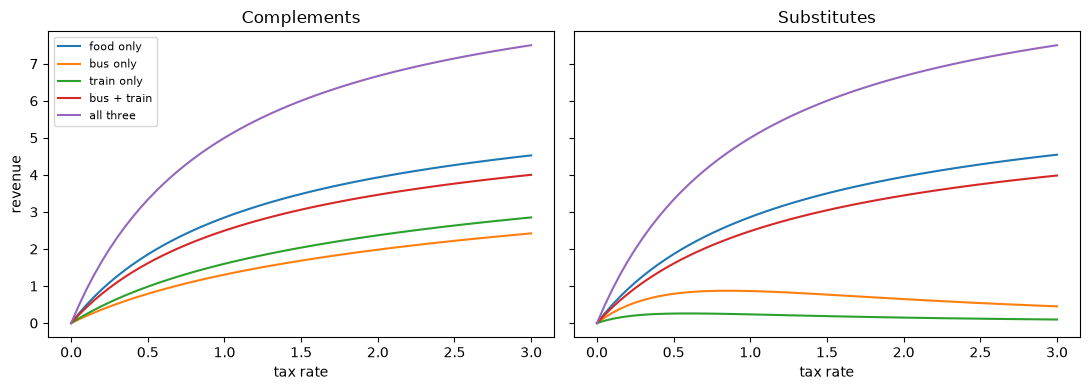

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, governments):
    d = df_tax[df_tax.calibration == name]
    for label in instruments:
        dd = d[d.instrument == label]
        ax.plot(dd.tau, dd.R, label=label)
    ax.set_xlabel('tax rate')
    ax.set_title(name)

axes[0].set_ylabel('revenue')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In `Complements` all five curves are still climbing at $\tau=3$. In `Substitutes`, `bus only` and `train only` visibly bend over and start *falling* well before $\tau=3$ -- the other three keep rising throughout.

### 4.3 Which curves have a top?

`.max_revenue()` grid-searches the tax rate, exactly as in section 2.1.

In [26]:
rows = []
for name, gov in governments.items():
    for label, goods in instruments.items():
        tau_star, R_star = gov.max_revenue(goods=goods, tau_max=3.0, N=1001)
        rows.append({'calibration': name, 'instrument': label, 'tau_star': tau_star, 'R_star': R_star,
                     'has_top (tau*<3.0)': tau_star < 3.0})

df_tops = pd.DataFrame(rows)
df_tops.round(4)

,calibration,instrument,tau_star,R_star,has_top (tau*<3.0)
0,Complements,food only,3.000,4.5261,False
1,Complements,bus only,3.000,2.4206,False
2,Complements,train only,3.000,2.8510,False
3,Complements,bus + train,3.000,4.0019,False
4,Complements,all three,3.000,7.5000,False
5,Substitutes,food only,3.000,4.5449,False
6,Substitutes,bus only,0.855,0.8721,True
7,Substitutes,train only,0.594,0.2590,True
8,Substitutes,bus + train,3.000,3.9823,False
9,Substitutes,all three,3.000,7.5000,False


In [27]:
row = df_tops[(df_tops.calibration == 'Substitutes') & (df_tops.instrument == 'train only')].iloc[0]
print(f"train alone, Substitutes: revenue tops out at R* = {row['R_star']:.4f}, "
      f"at a tax rate of tau* = {row['tau_star']:.4f}")

# how far does this hold up? push the search well past tau=3
tau_star_wide, R_star_wide = governments['Substitutes'].max_revenue(goods=(3,), tau_max=10.0, N=2001)
print(f"same search out to tau_max=10: tau* = {tau_star_wide:.4f}, R* = {R_star_wide:.4f} (unchanged)")

train alone, Substitutes: revenue tops out at R* = 0.2590, at a tax rate of tau* = 0.5940
same search out to tau_max=10: tau* = 0.5950, R* = 0.2590 (unchanged)


Only two of the ten curves have a top: `bus only` and `train only`, both in `Substitutes` -- the only calibration where the taxed good has a close substitute to flee to, so demand collapses fast enough that revenue eventually *falls* even as the rate keeps rising. Every other curve is still climbing at $\tau=3$ (checked out to $\tau=10$ too, with no change): with nothing to substitute towards (`Complements`), or with the whole travel nest taxed together so there is no untaxed escape route (`bus + train`, `all three`, and `food only`, which sits outside the nest entirely), a higher rate keeps winning over the shrinking base.

In `Substitutes`, a tax on **train tickets alone** can never raise more than $R^\star\approx0.259$ (2.6% of income), reached at $\tau^\star\approx0.594$ (a 59% tax) -- push the rate any higher and the collapsing quantity of train trips outweighs the higher rate.

### 4.4 Utility against revenue raised

For the lump-sum tax we sweep $T$ directly (income must stay positive); the five product taxes reuse the sweep from section 4.2.

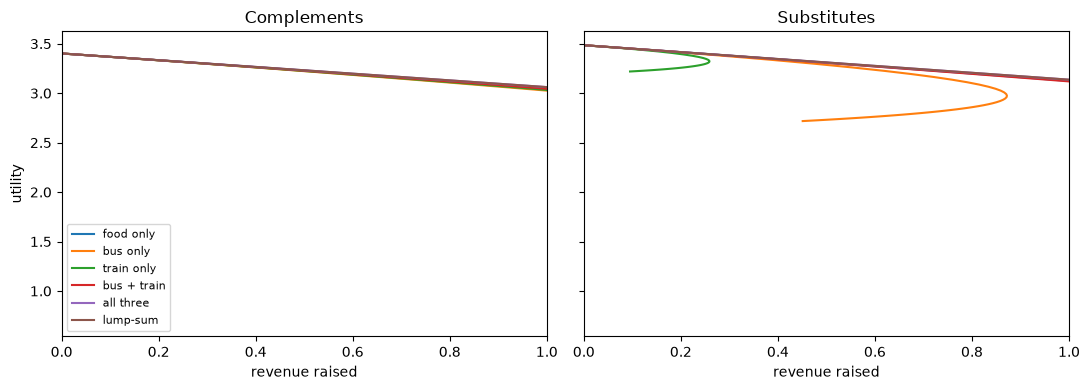

In [28]:
T_vec = np.linspace(0, 8, 50)

rows = []
for name, gov in governments.items():
    for T in T_vec:
        R, u = gov.revenue_and_utility_lump_sum(T)
        rows.append({'calibration': name, 'instrument': 'lump-sum', 'R': R, 'u': u})

df_lumpsum = pd.DataFrame(rows)
df_ru = pd.concat([df_tax[['calibration', 'instrument', 'R', 'u']], df_lumpsum], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, governments):
    d = df_ru[df_ru.calibration == name]
    for label in list(instruments) + ['lump-sum']:
        dd = d[d.instrument == label]  # keep natural tau/T order -- R is not monotonic in tau
        ax.plot(dd.R, dd.u, label=label)
    ax.set_xlabel('revenue raised')
    ax.set_xlim(0, 1.0)
    ax.set_title(name)

axes[0].set_ylabel('utility')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Zoomed in on revenue up to 1.0 (about 10% of income), since that already covers every instrument's realistic range. `all three` and `lump-sum` trace out the *same* curve in both panels -- taxing every good at the same rate turns out to be a lump-sum tax in disguise (section 4.5 shows why exactly). They sit on top everywhere: for the same revenue, every other instrument costs strictly more utility, because it distorts relative prices instead of just shrinking the budget. The ranking among the rest does shift with the calibration -- worked out precisely next.

### 4.5 Hitting a fixed revenue target: R = 0.20

For the product taxes, `find_tax_rate()`'s bracket is capped at that instrument's own revenue ceiling from `df_tops` -- for the eight instruments still rising at $\tau=3$ this is just $(10^{-10},3.0)$, but for `bus only`/`train only` in `Substitutes` it caps the search *before* the top of the Laffer curve, so brentq finds the low-tax root rather than failing on a bracket with the same sign at both ends (revenue is 0 at $\tau\to0$ and already falling back through the target by $\tau=3$). The lump-sum tax uses `optimize.root_scalar` directly, since `GovernmentClass` has no separate lump-sum finder.

In [29]:
R_target = 0.20

rows = []
for name, gov in governments.items():
    for label, goods in instruments.items():
        tau_ceiling = df_tops[(df_tops.calibration == name) & (df_tops.instrument == label)]['tau_star'].iloc[0]
        tau = gov.find_tax_rate(R_target, goods=goods, bracket=(1e-10, tau_ceiling))
        R, u = gov.revenue_and_utility(tau, goods=goods)
        rows.append({'calibration': name, 'instrument': label, 'rate': tau, 'R': R, 'u': u})

    f = lambda T: gov.revenue_and_utility_lump_sum(T)[0] - R_target
    T = optimize.root_scalar(f, bracket=(1e-10, 8.0), method='brentq').root
    R, u = gov.revenue_and_utility_lump_sum(T)
    rows.append({'calibration': name, 'instrument': 'lump-sum', 'rate': T, 'R': R, 'u': u})

df_r20 = pd.DataFrame(rows).sort_values(['calibration', 'u'], ascending=[True, False]).reset_index(drop=True)
df_r20.round(6)

,calibration,instrument,rate,R,u
0,Complements,all three,0.020408,0.2,3.333646
1,Complements,lump-sum,0.200000,0.2,3.333646
2,Complements,food only,0.038647,0.2,3.333169
3,Complements,bus + train,0.044787,0.2,3.333010
4,Complements,train only,0.081011,0.2,3.332548
5,Complements,bus only,0.104215,0.2,3.332260
6,Substitutes,lump-sum,0.200000,0.2,3.415402
7,Substitutes,all three,0.020408,0.2,3.415402
8,Substitutes,food only,0.038454,0.2,3.414919
9,Substitutes,bus + train,0.045049,0.2,3.414744


In [30]:
# the two roots on the train-alone / Substitutes Laffer curve, both raising R=0.20
gov = governments['Substitutes']
tau_low = gov.find_tax_rate(R_target, goods=(3,), bracket=(1e-10, 0.593))
tau_high = gov.find_tax_rate(R_target, goods=(3,), bracket=(0.593, 3.0))
_, u_low = gov.revenue_and_utility(tau_low, goods=(3,))
_, u_high = gov.revenue_and_utility(tau_high, goods=(3,))
print(f'low root:  tau = {tau_low:.4f}, u = {u_low:.6f}')
print(f'high root: tau = {tau_high:.4f}, u = {u_high:.6f}')

low root:  tau = 0.2362, u = 3.395521
high root: tau = 1.3572, u = 3.257095


**Ranking (best to worst utility, both calibrations):** `all three` and `lump-sum` tie for the best, then `food only`, then `bus + train`, then the two single travel-good taxes -- but *which* of `bus only`/`train only` is worse flips between calibrations. In `Complements`, `bus only` is worst ($u\approx3.3323$ at $\tau=10.4\%$); in `Substitutes`, **`train only` is by far the worst** ($u\approx3.3955$ at $\tau=23.6\%$) -- worse even than `bus only`, despite bus and train looking symmetric in the nest ($\beta=0.5$).

The reason is section 4.3's ceiling: train-alone in `Substitutes` can never raise more than $R^\star\approx0.259$, so reaching $R=0.20$ already spends most of the room that instrument has, at a rate several times higher than any other single-good tax needs (23.6% vs. 3.9-10.4% everywhere else). There is even a *second* rate, $\tau\approx135.7\%$, that raises exactly the same 0.20 on the far, falling side of that curve, at a far worse $u\approx3.257$ -- `find_tax_rate()`'s warning about two roots is not a hypothetical here, it is why the bracket above was capped at the top of the curve instead of left at $(10^{-10},3.0)$.

**The `all three` / `lump-sum` tie is exact, not approximate** (3.333646 vs. 3.333646 in `Complements`; 3.415402 vs. 3.415402 in `Substitutes`) -- and it is not a coincidence. Taxing every good at the same rate $\tau$ scales every price by $(1+\tau)$, which leaves *relative* prices -- and therefore the optimal budget shares -- completely unchanged; only the *real* budget shrinks, to $I/(1+\tau)$. That is exactly what a lump-sum tax does too, just parametrized differently. Formally, since the shares still sum to one,

$$R = \sum_j \tau p_j x_j = \tau\sum_j p_j x_j = \tau\cdot\frac{I}{1+\tau},$$

independent of $\alpha,\beta,\sigma_A,\sigma_B$ entirely -- solving $R=0.20$ gives $\tau=0.2/9.8\approx2.04\%$ in *both* calibrations, exactly what the table shows, and it is also why `all three`'s revenue curve in section 4.2 was identical in both panels ($R=7.50$ at $\tau=3$ either way).

## 5. Extension: a CO2 externality from travelling

Both bus and train trips cause CO2 emissions -- buses more so, since intercity buses mostly run on diesel while (Danish) trains run mostly on electricity. We extend the model so the consumer internalizes this directly: pollution enters their own utility, not just the atmosphere.

Emissions are linear in the two travel quantities,

$$E(x_2,x_3) = c_2 x_2 + c_3 x_3, \qquad c_2 > c_3 > 0,$$

and utility becomes

$$U(x_1,x_2,x_3) = u(x_1,x_2,x_3) - \gamma\, E(x_2,x_3), \qquad \gamma>0,$$

where $u(\cdot)$ is exactly the nested CES utility from eq. 2, completely untouched, and $\gamma$ is the marginal disutility of one kg of CO2. We use $c_2=0.90$, $c_3=0.30$ kg CO2 per trip -- a bus trip pollutes three times as much as a train trip -- and $\gamma=0.15$: round numbers, not measured ones, picked only to give a shift worth looking at.

`ExternalityConsumerClass` in `Python_module.py` implements this. It inherits everything from `ConsumerClass`, adds `c2`, `c3`, `gamma` in `.setup()`, and overrides only `.value_of_choice()` to subtract $\gamma E$ from ordinary utility. Since `.solve()` and `.solve_grid()` are both written in terms of `.value_of_choice()` (via `.objective()`), they are inherited completely unchanged and automatically solve the *right* problem -- exactly the same trick `GovernmentClass` used in section 4.

### 5.1 Does the utility-maximizing bundle change?

In [31]:
from Python_module import ExternalityConsumerClass

ext_models = {name: ExternalityConsumerClass(par={'sigma_B': sB}) for name, sB in sigma_B.items()}

rows = []
for name, sB in sigma_B.items():
    # a. baseline: no externality at all (section 2's answer)
    base = models[name]
    opt_base = base.solve(do_print=False)
    x1b, x2b, x3b = base.quantities(opt_base.s1, opt_base.w)

    # b. the same consumer, now internalizing the CO2 externality
    ext = ext_models[name]
    opt_ext = ext.solve(do_print=False)
    x1e, x2e, x3e = ext.quantities(opt_ext.s1, opt_ext.w)

    Eb = ext.emissions(x2b, x3b)
    Ee = ext.emissions(x2e, x3e)
    u_priv_e = ext.utility(x1e, x2e, x3e)  # ordinary CES utility, for a fair comparison

    rows.append({'calibration': name, 'case': 'baseline', 's1': opt_base.s1, 's2': opt_base.s2, 's3': opt_base.s3,
                 'x1': x1b, 'x2': x2b, 'x3': x3b, 'u (private)': opt_base.u, 'CO2 (kg)': Eb})
    rows.append({'calibration': name, 'case': 'with externality', 's1': opt_ext.s1, 's2': opt_ext.s2, 's3': opt_ext.s3,
                 'x1': x1e, 'x2': x2e, 'x3': x3e, 'u (private)': u_priv_e, 'CO2 (kg)': Ee})

df_ext = pd.DataFrame(rows)
df_ext.round(4)

,calibration,case,s1,s2,s3,x1,x2,x3,u (private),CO2 (kg)
0,Complements,baseline,0.5356,0.2041,0.2603,5.3562,2.0408,1.7353,3.4017,2.3573
1,Complements,with externality,0.5777,0.1744,0.2479,5.7771,1.7439,1.6527,3.3805,2.0653
2,Substitutes,baseline,0.5382,0.3197,0.1421,5.3823,3.1969,0.9472,3.4851,3.1614
3,Substitutes,with externality,0.5836,0.2081,0.2082,5.8364,2.0812,1.3883,3.4237,2.2896


Yes -- the bundle moves in both calibrations, and it moves *differently*:

`Complements` cannot substitute bus for train ($\sigma_B=0.40$), so internalizing CO2 pulls **both** travel goods down together (bus share 0.204 -> 0.174, train share 0.260 -> 0.248) while food absorbs the released budget (0.536 -> 0.578). Emissions fall 12%, at a private-utility cost of only 0.6%.

`Substitutes` swaps bus for train almost trip-for-trip instead ($\sigma_B=3.00$): bus share collapses (0.320 -> 0.208) while train share actually *rises* (0.142 -> 0.208) to very nearly replace it. Because switching is nearly free here, `Substitutes` buys almost as much total travel as before, just cleaner -- which is exactly why its emissions fall by more (28% vs. 12%), for a still-modest private-utility cost (1.8%).

This is the same complements/substitutes split as section 3's price sweep: unable to substitute, `Complements` cuts both goods together; free to substitute, `Substitutes` reshuffles between them instead.

### 5.2 How much does this depend on how strongly the consumer cares?

We sweep $\gamma$ from 0 (section 2's answer) up to 0.6, exactly as section 3 swept $p_3$.

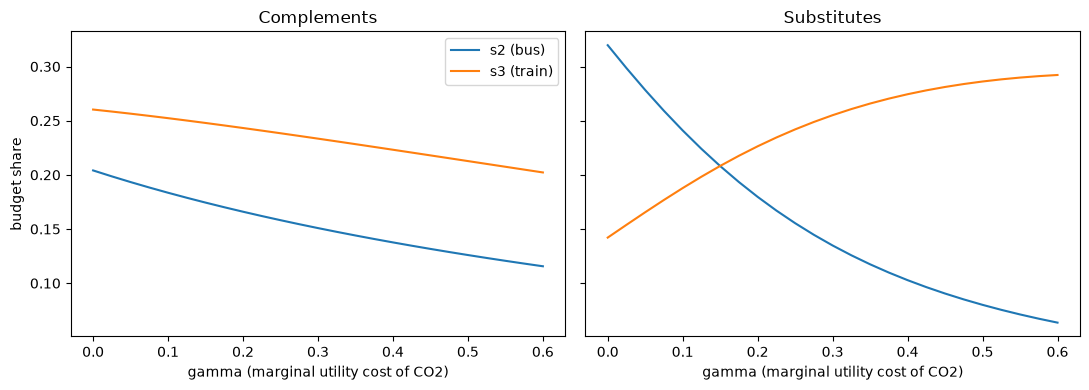

In [32]:
gamma_vec = np.linspace(0, 0.6, 25)

rows = []
for name, sB in sigma_B.items():
    for gamma in gamma_vec:
        model = ExternalityConsumerClass(par={'sigma_B': sB, 'gamma': gamma})
        opt = model.solve(do_print=False)
        x1, x2, x3 = model.quantities(opt.s1, opt.w)
        E = model.emissions(x2, x3)
        rows.append({'calibration': name, 'gamma': gamma, 's2': opt.s2, 's3': opt.s3, 'CO2 (kg)': E})

df_gamma = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, sigma_B):
    d = df_gamma[df_gamma.calibration == name]
    ax.plot(d.gamma, d.s2, label='s2 (bus)')
    ax.plot(d.gamma, d.s3, label='s3 (train)')
    ax.set_xlabel('gamma (marginal utility cost of CO2)')
    ax.set_title(name)

axes[0].set_ylabel('budget share')
axes[0].legend()
plt.tight_layout()
plt.show()

Both calibrations respond smoothly, with no jumps. In `Complements`, `s2` and `s3` decline together and never cross -- train keeps its larger share throughout. In `Substitutes`, the two curves visibly *cross* around $\gamma\approx0.15$ (our chosen value sits almost exactly at the point where bus and train swap places) and keep diverging afterwards, with train ending up the larger share by $\gamma=0.6$. Pushed far enough, a high enough carbon cost would eventually price bus out of `Substitutes` almost entirely -- but nowhere in this range does either share hit a corner, so the mechanism is a smooth reallocation, not a cliff.

**Summary.** Internalizing a CO2 externality that is larger for bus than for train does change the utility-maximizing bundle in both calibrations -- less travel and more food where goods cannot be substituted, and a straight swap from the dirtier to the cleaner good where they can -- and in both cases it lowers emissions by considerably more than it costs in private utility.